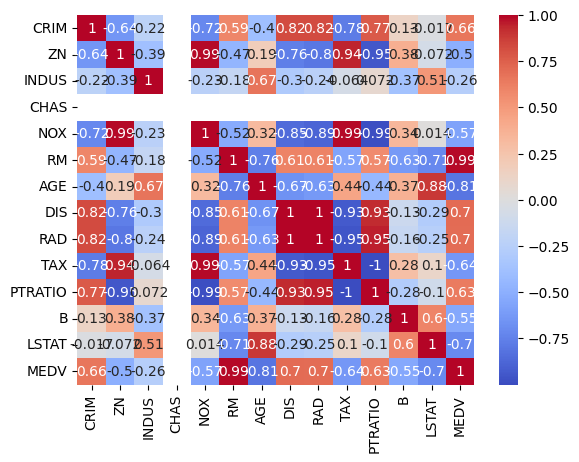

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv")
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


In [3]:
corr_medv = corr["MEDV"].drop("MEDV").abs().sort_values(ascending=False)
top2_features = corr_medv.head(2)
print("Top 2 features:", top2_features.index.tolist())


Top 2 features: ['RM', 'AGE']


In [4]:
from sklearn.model_selection import train_test_split

X = df[top2_features.index]
y = df["MEDV"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)


RMSE: 2.0272020391006365
